In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    roc_curve, auc, confusion_matrix
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Pipeline: StandardScaler -> PCA -> AdaBoost with DecisionTree
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),   # PCA step (tuneable n_components)
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])


In [6]:
param_grid = {
    "pca__n_components": [5, 10, 15, 20],  # Tune PCA dimensions
    "clf__n_estimators": [50, 100, 200],
    "clf__learning_rate": [0.01, 0.1, 1.0],
    "clf__estimator__max_depth": [1, 2]
}

In [11]:
# 6. GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # only accuracy
    refit=True,           # best model refitted using accuracy
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__estimator__max_depth': [1, 2], 'clf__learning_rate': [0.01, 0.1, ...], 'clf__n_estimators': [50, 100, ...], 'pca__n_components': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [13]:
results = pd.DataFrame(grid.cv_results_)

table = results[[
    "param_pca__n_components",
    "param_clf__n_estimators",
    "param_clf__learning_rate",
    "param_clf__estimator__max_depth",
    "mean_test_score"
]].copy()

table = table.rename(columns={
    "param_pca__n_components": "n_components",
    "param_clf__n_estimators": "n_estimators",
    "param_clf__learning_rate": "learning_rate",
    "param_clf__estimator__max_depth": "max_depth",
    "mean_test_score": "Accuracy"
})

# Top 5 by accuracy
top5 = table.sort_values(by="Accuracy", ascending=False).head(5)

print("\nTop 5 Hyperparameter Settings by Accuracy")
print(top5)

# Best hyperparameters
print("\nBest Hyperparameters (from training CV):", grid.best_params_)
print("\nBest Acc: ",grid.best_score_)



Top 5 Hyperparameter Settings by Accuracy
    n_components  n_estimators  learning_rate  max_depth  Accuracy
70            15           200            1.0          2  0.975824
66            15           100            1.0          2  0.973626
62            15            50            1.0          2  0.971429
29            10           100            1.0          1  0.971429
33            10           200            1.0          1  0.969231

Best Hyperparameters (from training CV): {'clf__estimator__max_depth': 2, 'clf__learning_rate': 1.0, 'clf__n_estimators': 200, 'pca__n_components': 15}

Best Acc:  0.9758241758241759


In [15]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))



Test Accuracy: 0.9736842105263158
Test Precision: 0.975609756097561
Test Recall: 0.9523809523809523
Test F1: 0.963855421686747
Test ROC AUC: 0.9930555555555556


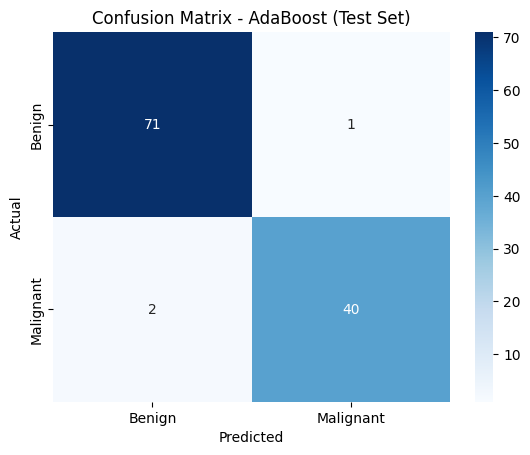

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign","Malignant"],
            yticklabels=["Benign","Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - AdaBoost (Test Set)")
plt.show()

/tmp/ipykernel_8887/2610839020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


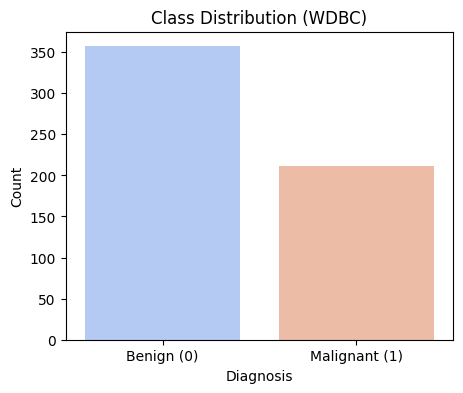

/tmp/ipykernel_8887/2610839020.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


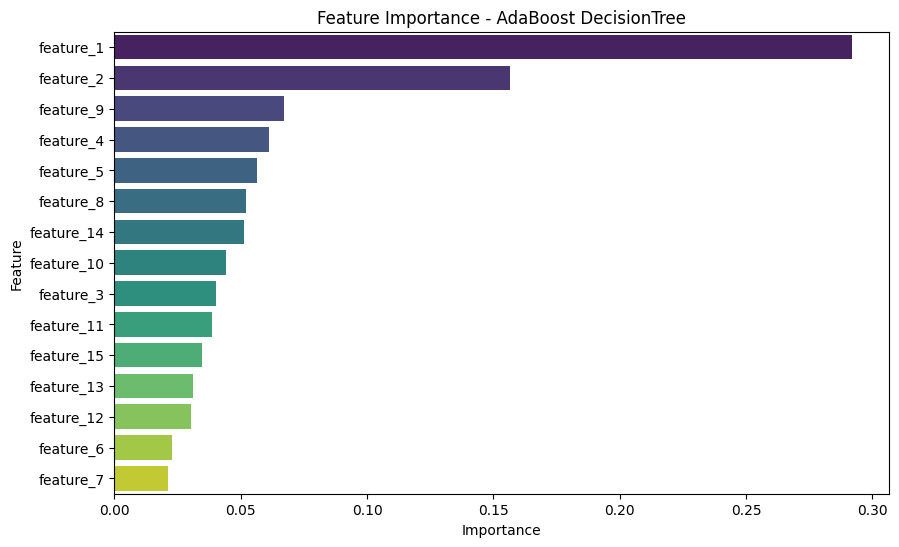

In [20]:
# Class distribution
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette="coolwarm")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution (WDBC)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Feature importance from best AdaBoost DecisionTree
best_clf = best_model.named_steps["clf"]
importances = best_clf.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance - AdaBoost DecisionTree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [19]:
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Best AdaBoost model from GridSearch
best_ab = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=grid.best_params_['clf__estimator__max_depth'],
        random_state=42
    ),
    n_estimators=grid.best_params_['clf__n_estimators'],
    learning_rate=grid.best_params_['clf__learning_rate'],
    random_state=42
)

# Pipeline with scaling + PCA + classifier
pipe_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=grid.best_params_['pca__n_components'])),  # Add PCA
    ("clf", best_ab)
])

# 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring="accuracy")

# Print each fold accuracy and average
for i, acc in enumerate(cv_acc, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")
print(f"Average 5-Fold CV Accuracy: {cv_acc.mean():.4f}")


Fold 1 Accuracy: 0.9670
Fold 2 Accuracy: 0.9890
Fold 3 Accuracy: 0.9560
Fold 4 Accuracy: 0.9890
Fold 5 Accuracy: 0.9780
Average 5-Fold CV Accuracy: 0.9758
